# Created by Rishik Vempati (AI24MTECH12003@iith.ac.in) and Debanjan Das (AI24MTECH12009@iith.ac.in) for AIET July-2026(cohort 9) under the guidance of Dr. Konda Reddy Mopuri.

Chort Details : Ganesh Pilli , 2251460

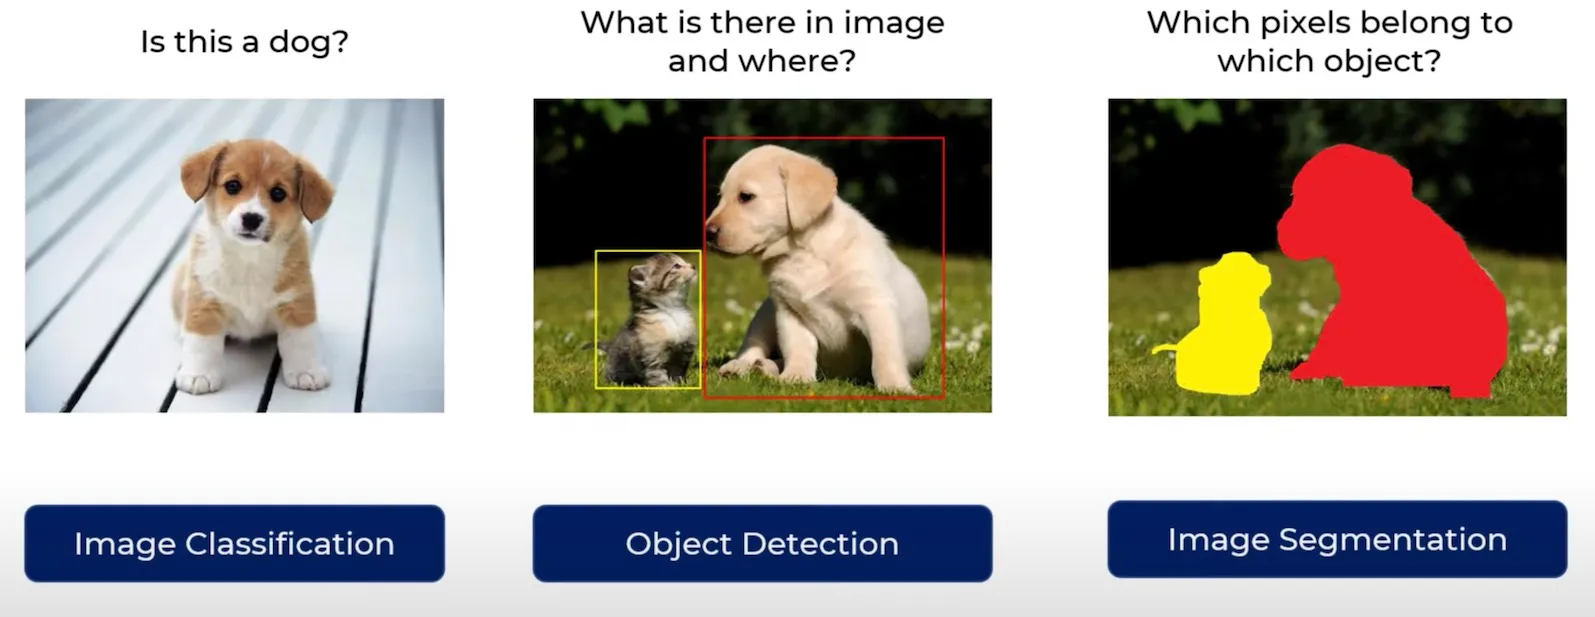

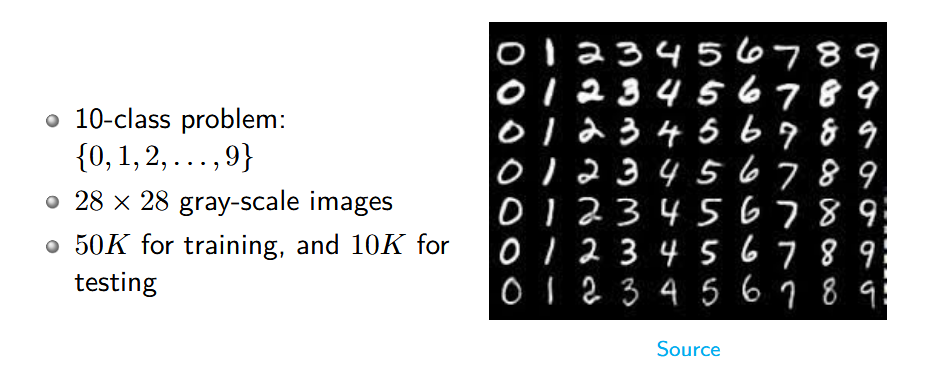

# Goal

Implement a classical image classification pipeline on the MNIST dataset using the K-Nearest Neighbors (KNN) algorithm.

## Workflow

1. Train a KNN classifier using raw pixel intensities as feature vectors.
2. Tune the hyperparameter **K** using a separate validation set.
3. Evaluate the selected model on the test set to measure its generalization performance.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.datasets import mnist

In [15]:
np.random.seed(42)

# Data Preparation

We begin by loading the **MNIST** handwritten digit dataset and normalizing the pixel values from **[0, 255]** to **[0, 1]**. Normalization ensures that all features are on a consistent scale, which can improve the performance and stability of many machine learning algorithms.

The dataset is then split into three subsets:

- **Training Set** – Used to train (fit) the K-Nearest Neighbors (KNN) classifier.
- **Validation Set** – Used to tune hyperparameters, such as selecting the optimal value of **K**, without exposing the model to the test data.
- **Test Set** – Kept completely unseen during training and hyperparameter tuning, and used **only once** to evaluate the final model's generalization performance.

In [16]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

X_train_full = X_train_full.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

X_train_full_flat = X_train_full.reshape(len(X_train_full), -1)

X_test_flat = X_test.reshape(len(X_test), -1)

# Train/Val split
X_train_flat, X_val_flat, y_train, y_val = train_test_split(
    X_train_full_flat, y_train_full,
    test_size=10_000,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train_flat.shape, y_train.shape)
print("Val:  ", X_val_flat.shape, y_val.shape)
print("Test: ", X_test_flat.shape, y_test.shape)

Train: (50000, 784) (50000,)
Val:   (10000, 784) (10000,)
Test:  (10000, 784) (10000,)


In [17]:
# Keep a smaller subset for quick experiments

N_TRAIN = 8000
N_VAL = 2000
N_TEST = 2000

X_train_sub, y_train_sub = X_train_flat[:N_TRAIN], y_train[:N_TRAIN]
X_val_sub, y_val_sub = X_val_flat[:N_VAL], y_val[:N_VAL]
X_test_sub, y_test_sub = X_test_flat[:N_TEST], y_test[:N_TEST]

print("\nSubsets for class:")
print("Train sub:", X_train_sub.shape)
print("Val sub:  ", X_val_sub.shape)
print("Test sub: ", X_test_sub.shape)


Subsets for class:
Train sub: (8000, 784)
Val sub:   (2000, 784)
Test sub:  (2000, 784)


In [18]:
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_flat,
    y_train,
    train_size=N_TRAIN,
    stratify=y_train,
    random_state=42
)

X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_flat,
    y_train,
    train_size=N_TRAIN,
    stratify=y_train,
    random_state=42
)

X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_flat,
    y_train,
    train_size=N_TRAIN,
    stratify=y_train,
    random_state=42
)

# Visualizing the Dataset

Before training any machine learning model, it is good practice to **inspect the data**. Visualizing a few randomly selected samples helps verify that:

- The images have been loaded correctly.
- The labels correspond to the correct handwritten digits.
- The preprocessing steps (such as normalization and reshaping) have not introduced any errors.

This simple sanity check can help detect data-related issues early, before investing time in model training and evaluation.

In [19]:
def show_samples(X_flat, y, n=12, title="Samples"):
    plt.figure(figsize=(12, 2))
    idxs = np.random.choice(len(X_flat), size=n, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(1, n, i+1)
        plt.imshow(X_flat[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(str(int(y[idx])))
    plt.suptitle(title)
    plt.show()

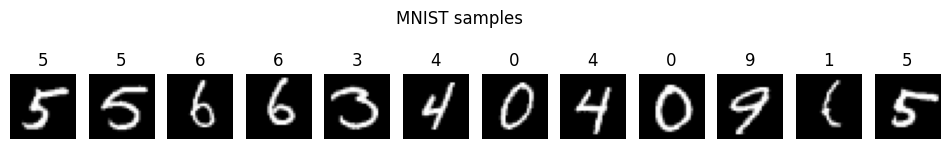

In [20]:
show_samples(X_train_sub, y_train_sub, n=12, title="MNIST samples")

# K-Nearest Neighbors (KNN) Classifier 
 **Complete by adding the alog below**
The **K-Nearest Neighbors (KNN)** algorithm is a simple, non-parametric, instance-based learning method. Unlike many machine learning models, KNN does not learn an explicit model during training. Instead, it **stores all training samples** and performs computation only when making predictions.

For a given test image, KNN follows these steps:

1. Compute the distance between the test image and every training image in the dataset.
2. Identify the **K** training images with the smallest distances (the nearest neighbors).
3. Predict the class of the test image using a **majority vote** among these K neighbors.

In [21]:
k = 3
knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
knn.fit(X_train_sub, y_train_sub)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [22]:
val_pred = knn.predict(X_val_sub)
val_acc = accuracy_score(y_val_sub, val_pred)

print(f"Validation accuracy with K={k}: {val_acc:.4f}")

Validation accuracy with K=3: 0.9415


# Selecting the Optimal Value of K

The performance of a K-Nearest Neighbors (KNN) classifier depends heavily on the choice of **K**. A small value of K may make the model sensitive to noise, while a large value may oversmooth the decision boundaries.

Evaluate the classifier using several values of **K** and compare their validation accuracies.

As you experiment, consider the following questions:

- Which value of **K** achieves the highest validation accuracy?
- Does the validation accuracy consistently improve as **K** increases?
- Based on your results, which value of **K** would you choose for the final model, and why?

In [23]:
# DIY
# DIY: change these K values and run again
K_VALUES = [1, 3, 5, 7, 9, 11]

val_scores = {}

for k in K_VALUES:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_sub, y_train_sub)
    val_pred = knn.predict(X_val_sub)
    val_scores[k] = accuracy_score(y_val_sub, val_pred)

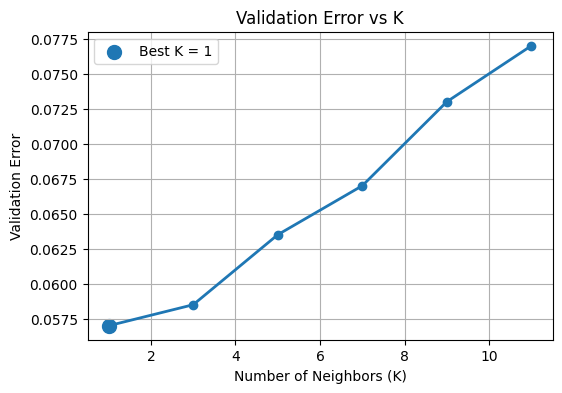

In [24]:
val_errors = [1 - val_scores[k] for k in K_VALUES]

plt.figure(figsize=(6,4))
plt.plot(K_VALUES,
         val_errors,
         marker='o',
         linewidth=2)

best_idx = val_errors.index(min(val_errors))
best_k = K_VALUES[best_idx]

plt.scatter(best_k,
            min(val_errors),
            s=100,
            label=f"Best K = {best_k}")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation Error")
plt.title("Validation Error vs K")
plt.grid(True)
plt.legend()

plt.show()

# Final Evaluation on the Test Set

After identifying the optimal value of **K** using the validation set, we **freeze** this hyperparameter and train the final KNN classifier.

The model is then evaluated **once** on the held-out test set. Since the test set has not been used during training or hyperparameter tuning, it provides an **unbiased estimate** of how well the classifier generalizes to unseen data.

In [25]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_best.fit(X_train_sub, y_train_sub)

test_pred = knn_best.predict(X_test_sub)
test_acc = accuracy_score(y_test_sub, test_pred)

print(f"Test accuracy with best K={best_k}: {test_acc:.4f}")

Test accuracy with best K=1: 0.9190


# Exercise: Does More Training Data Improve Performance?

In many machine learning tasks, providing more training data helps the model generalize better. \
In this exercise, we will investigate how the performance of a K-Nearest Neighbors (KNN) classifier changes as the size of the training set increases.

Keep the **best value of K** fixed (selected using the validation set) and train the classifier using different numbers of training samples.

In [26]:
TRAIN_SIZES = [2000, 5000, 8000, 12000]

results = {}
for n in TRAIN_SIZES:
    X_tr, y_tr = X_train_flat[:n], y_train[:n]
    model = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val_sub)
    results[n] = accuracy_score(y_val_sub, pred)

print("Validation accuracy vs training size:")
for n in TRAIN_SIZES:
    print(f"n_train={n:<5} val_acc={results[n]:.4f}")

Validation accuracy vs training size:
n_train=2000  val_acc=0.9010
n_train=5000  val_acc=0.9285
n_train=8000  val_acc=0.9410
n_train=12000 val_acc=0.9470


A confusion matrix shows which digits are commonly confused.
This helps us understand failure modes beyond just “accuracy”.

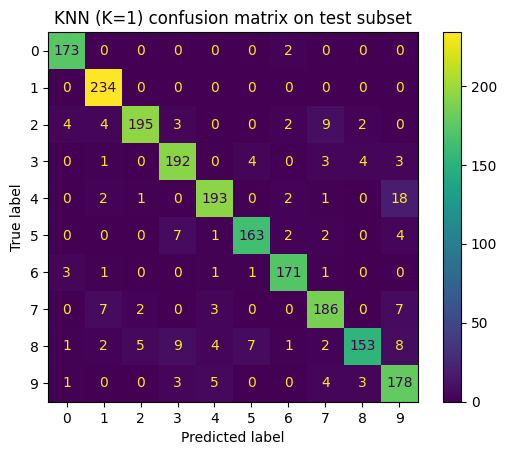

In [27]:
cm = confusion_matrix(y_test_sub, test_pred, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(values_format="d")
plt.title(f"KNN (K={best_k}) confusion matrix on test subset")
plt.show()

# Analyzing Model Predictions

To better understand the behavior of the KNN classifier, we inspect individual predictions rather than relying solely on numerical metrics.

We will display a few:

- **Correctly classified** test images to see examples the model recognizes confidently.
- **Incorrectly classified** test images to investigate common failure cases and visually similar digits.

This qualitative analysis complements the confusion matrix and provides deeper insight into the strengths and weaknesses of the classifier.

In [28]:
def show_correct_incorrect(X_flat, y_true, y_pred, n_show=5):
    # Indices of correct and incorrect predictions
    correct_idx = np.where(y_true == y_pred)[0]
    incorrect_idx = np.where(y_true != y_pred)[0]

    correct_pick = np.random.choice(
        correct_idx,
        size=min(n_show, len(correct_idx)),
        replace=False
    )

    incorrect_pick = np.random.choice(
        incorrect_idx,
        size=min(n_show, len(incorrect_idx)),
        replace=False
    )

    plt.figure(figsize=(2 * n_show, 4))

    # ------------------------
    # Top row: Correct
    # ------------------------
    for i, idx in enumerate(correct_pick):
        plt.subplot(2, n_show, i + 1)
        plt.imshow(X_flat[idx].reshape(28, 28), cmap="gray")
        plt.title(f"True={y_true[idx]}\nPred={y_pred[idx]}")
        plt.axis("off")

    # ------------------------
    # Bottom row: Incorrect
    # ------------------------
    for i, idx in enumerate(incorrect_pick):
        plt.subplot(2, n_show, n_show + i + 1)
        plt.imshow(X_flat[idx].reshape(28, 28), cmap="gray")
        plt.title(f"True={y_true[idx]}\nPred={y_pred[idx]}")
        plt.axis("off")

    plt.suptitle("Correct Predictions (Top) vs Incorrect Predictions (Bottom)")
    plt.tight_layout()
    plt.show()

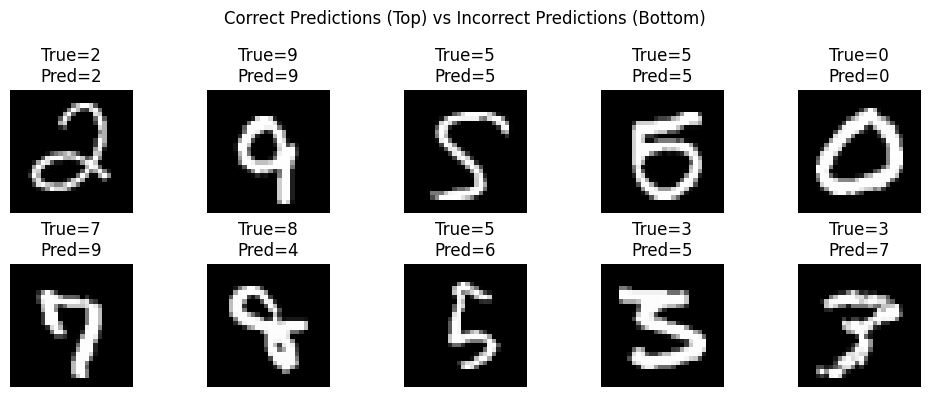

In [29]:
show_correct_incorrect(
    X_test_sub,
    y_test_sub,
    test_pred,
    n_show=5
)

# DIY: Applying KNN to Fashion-MNIST

The handwritten digits in the MNIST dataset are relatively simple and well-separated. \
To evaluate how K-Nearest Neighbors (KNN) performs on a more challenging image classification task, we will repeat the same workflow using the **Fashion-MNIST** dataset.

Fashion-MNIST consists of **10 classes of grayscale clothing items**, such as T-shirts, trousers, dresses, shoes, bags etc.\
Although the images have the same size (**28 × 28 pixels**) as MNIST, the classes are more visually similar, making the classification problem more difficult.

In this exercise, we will:

1. Load the **Fashion-MNIST** dataset.
2. Normalize and flatten each image into a **784-dimensional feature vector**.
3. Split the data into training, validation, and test sets.
4. Tune the hyperparameter **K** using the validation set.
5. Evaluate the final KNN classifier on the test set and compare its performance with MNIST.

# Goal

Learn the fundamentals of **linear binary classification** using the **Perceptron algorithm**, one of the earliest and simplest machine learning models.

## Objectives

- Understand how the Perceptron represents a **linear decision boundary**.
- Train a Perceptron classifier on a **binary classification** problem.
- Visualize how the decision boundary evolves during training.
- Evaluate the trained model on unseen data and analyze its performance.

In [30]:
num_samples = 1000

# 55% of one class - 1, 45% of class - 0
num_class_1 = int(0.55 * 1000)
num_class_0 = (num_samples - num_class_1)

#### Generating the points for both the classes

In [31]:
# Ensuring linearly separable data by generating points of one class in [0, 2) and other class in [-2, 0)

class_1 = np.random.rand(num_class_1, 2) * 2

class_0 = (np.random.rand(num_class_0, 2) * 2) - 2

X = np.vstack((class_1, class_0))

y = np.hstack((np.ones(num_class_1), np.zeros(num_class_0))).reshape(-1, 1)

In [32]:
print(X.shape)

(1000, 2)


In [33]:
print(X[0])

[0.78399609 0.73740585]


#### Plotting the Linearly Separable Data

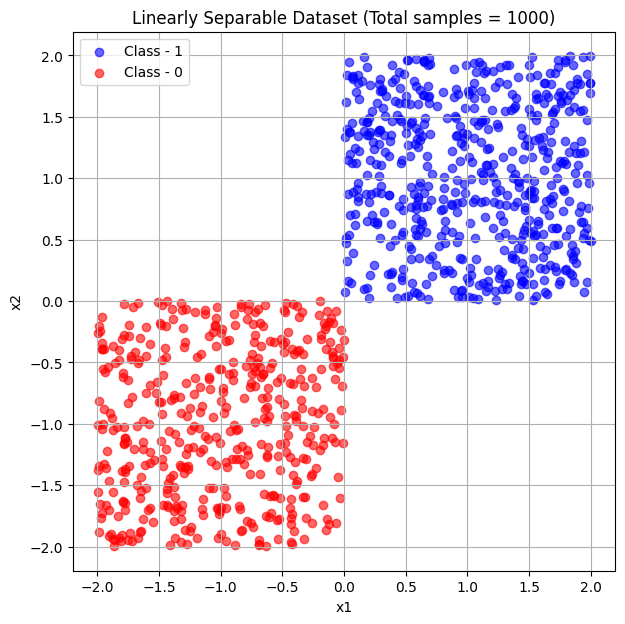

In [34]:
plt.figure(figsize=(7, 7))
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class - 1', alpha=0.6)

plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class - 0', alpha=0.6)

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()

plt.title(f'Linearly Separable Dataset (Total samples = {num_samples})')
plt.grid(True)

plt.show()

#### PERCEPTRON LEARNING ALGORITHM

In [35]:
# Converting the labels from {0, +1} to {-1, +1}
y = 2*y - 1

# Initialisation of Parameters (Weights)

# w*x

# +1(y) : w(x) > 0
# -1(y) : w(x) < 0

# y*(wx) > 0

# y*(wx) < 0 --- Misclassification condition
# w(new) = w(old) - (eta)*(grad(w))
# w(new) = w(old) + (eta)*(y*(wx))

w = np.zeros((2, 1))

# X[i] : [2, 1]
# w : [2, 1]

# [1, 2] * [2, 1]

lr = 1

# As the data generated above is linearly separable, perceptron algorithm definitely converges
while(True):
    m = 0
    for i in range(num_samples):
        if ((y[i] * (w.T @ X[i].reshape(-1, 1)))[0] <= 0):
            w = w + (lr * y[i] * X[i].reshape(-1, 1))
            m = m + 1

    if (m == 0):
        break

print(f'Perceptron Learning Algorithm is completed!!')
print(f'Optimal Weight vector {w.T}')

Perceptron Learning Algorithm is completed!!
Optimal Weight vector [[0.78399609 0.73740585]]


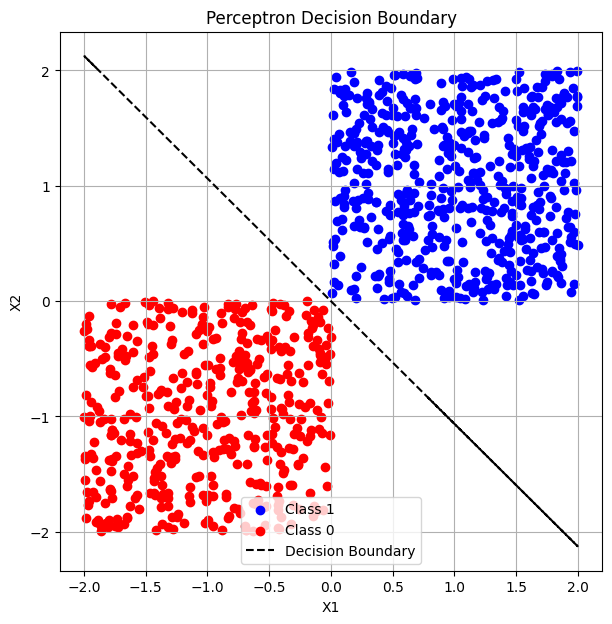

In [36]:
plt.figure(figsize=(7, 7))

y_flat = y.flatten()

plt.scatter(X[y_flat == 1][:, 0], X[y_flat == 1][:, 1], color='blue', label='Class 1')
plt.scatter(X[y_flat == -1][:, 0], X[y_flat == -1][:, 1], color='red', label='Class 0')

x_vals = X[:, 0]
y_vals = - (w[0].item() / w[1].item()) * x_vals

# w1x1 + w2x2

# w1x1 + w2x2 = 0
# w2x2 = -w1x1
# x2 = (-w1/w2)x1

plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()


plt.title('Perceptron Decision Boundary')
plt.grid(True)

plt.show()

#### Adding noise to the dataset by flipping 10% of the data points

In [37]:
num_flip = int(0.1 * num_samples)

# Randomly select indices to flip (without replacement)
flip_indices = np.random.choice(num_samples, num_flip, replace=False)

y_noisy = y.copy().reshape(-1, 1)
# Flipping the labels at the selected indices
for idx in flip_indices:
    y_noisy[idx] = -y_noisy[idx]

print("Label noise added successfully!")

Label noise added successfully!


#### Plotting the Noisy Dataset

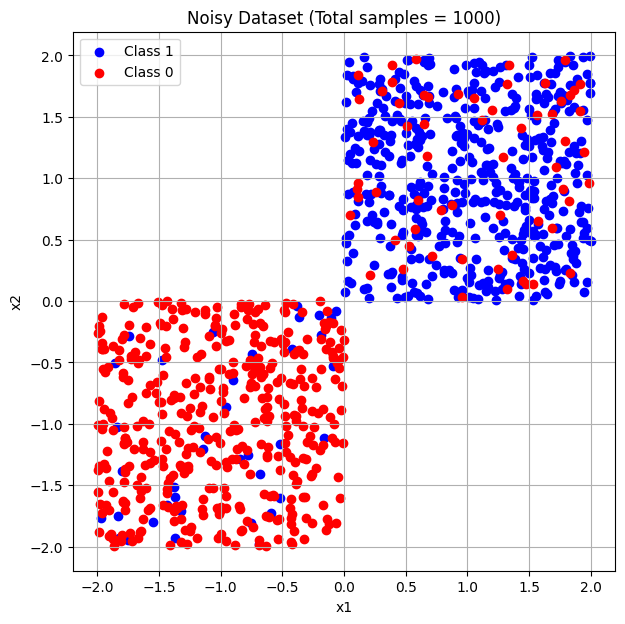

In [38]:
plt.figure(figsize=(7, 7))

y_flat_noisy = y_noisy.flatten()
plt.scatter(X[y_flat_noisy == 1][:, 0], X[y_flat_noisy == 1][:, 1], color='blue', label='Class 1')
plt.scatter(X[y_flat_noisy == -1][:, 0], X[y_flat_noisy == -1][:, 1], color='red', label='Class 0')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()

plt.title(f'Noisy Dataset (Total samples = {num_samples})')
plt.grid(True)

plt.show()

##### As the dataset is not linearly separable, perceptron algorithm never converges and hence implementing perceptron learning algorithm with '3' different cases having different number of iterations

In [39]:
epochs = [100, 500, 1000]
weight_vectors_perceptron = {}
misclassifications_perceptron = {}

for max_iters in epochs:
    # Initialisation of Parameters (Weights)
    w = np.zeros((2, 1))
    lr = 1

    # Keeps track of number of misclassifications for max_iters
    misclassification_count = 0

    print(f'\nTraining Perceptron for {max_iters} iterations...')

    for e in range(max_iters):
        m = 0
        for i in range(num_samples):
            if ((y_noisy[i] * (w.T @ X[i].reshape(-1, 1)))[0] <= 0):
                w = w + (lr * y_noisy[i] * X[i].reshape(-1, 1))
                m = m + 1

        misclassification_count = m

        if (m == 0):
            break

    weight_vectors_perceptron[max_iters] = w.T
    misclassifications_perceptron[max_iters] = misclassification_count

    print(f'Final Weight Vector for {max_iters} iterations: {w.T}')
    print(f'Misclassifications in case of {max_iters} iterations: {misclassifications_perceptron[max_iters]}')
    print(f'\n')


Training Perceptron for 100 iterations...
Final Weight Vector for 100 iterations: [[-0.1174078   0.73282106]]
Misclassifications in case of 100 iterations: 190



Training Perceptron for 500 iterations...
Final Weight Vector for 500 iterations: [[0.3599556  0.71246106]]
Misclassifications in case of 500 iterations: 186



Training Perceptron for 1000 iterations...
Final Weight Vector for 1000 iterations: [[ 1.02691891 -0.15414246]]
Misclassifications in case of 1000 iterations: 183




#### Decision Boundary For The Above Noisy in case of 3 iterations

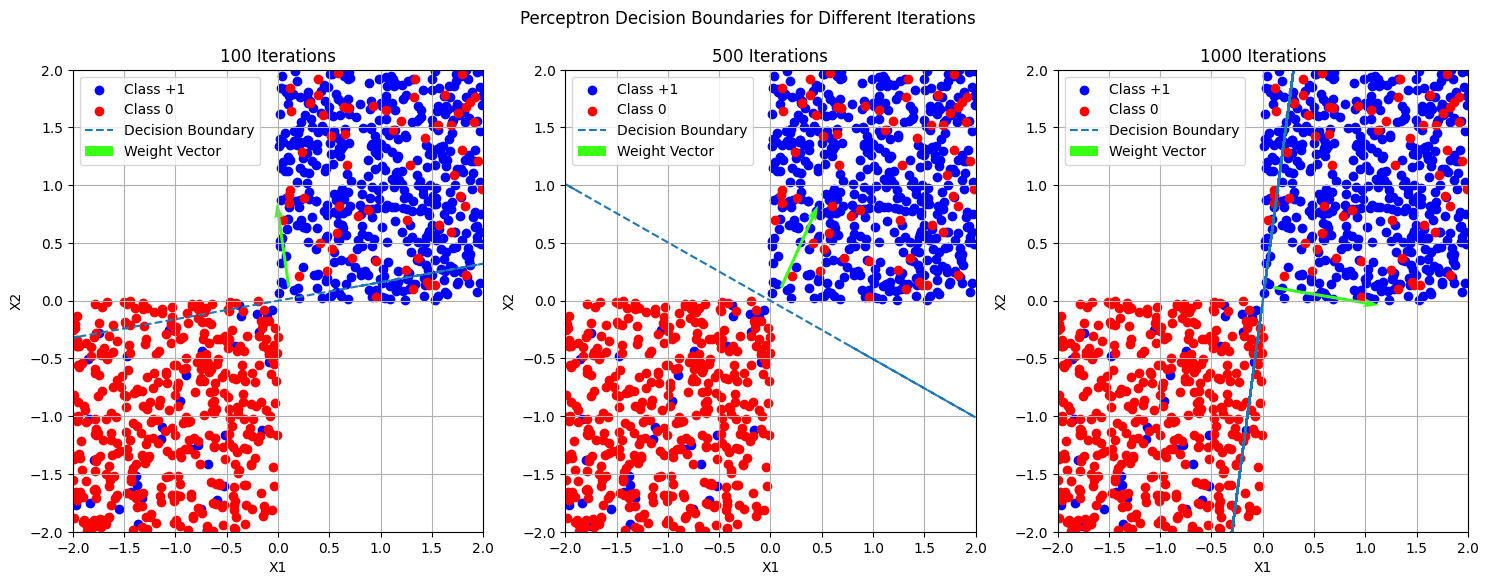

In [ ]:
plt.figure(figsize=(18, 6))

for idx, max_iters in enumerate(epochs):
    w = weight_vectors_perceptron[max_iters].T

    # Create subplots (1 row, 3 cols)
    plt.subplot(1, 3, idx + 1)

    # Plotting the data points
    y_flat_noisy = y_noisy.flatten()
    plt.scatter(X[y_flat_noisy == 1][:, 0], X[y_flat_noisy == 1][:, 1], color='blue', label='Class +1')
    plt.scatter(X[y_flat_noisy == -1][:, 0], X[y_flat_noisy == -1][:, 1], color='red', label='Class 0')

 # have some gaps in the Object detection notebook, so I will continue from where it left off.
    x_vals = X[:, 0]
    y_vals = - (w[0] / w[1]) * x_vals
    
    # Plotting the decision boundary
    plt.plot(x_vals, y_vals, '--', label='Decision Boundary')

    # Plotting the corresponding weight vectors
    origin = np.mean(X, axis=0)
    plt.quiver(*origin, 5*w[0, 0], 5*w[1, 0], scale=5, color='#39FF14', angles='xy', scale_units='xy', label='Weight Vector')

    plt.xlim(-2, 2)
    plt.ylim(-2, 2)

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()

    plt.title(f'{max_iters} Iterations')
    plt.grid(True)

plt.suptitle("Perceptron Decision Boundaries for Different Iterations")
plt.show()